### Conclusions

- Range of the cars sale date between start of 2014 and middle of 2015. Range of cars manufactured year 1982-2015. In analysis after cleaning from 1990.
- Prices heavily right skewed. It is normal for the prices, there are small amount of cars which prices are very high. Main quantity of cars below 35000.
- Mileage of the cars also right skewed. 10375/558837 ratio or 1.85%, main quantity of cars mileage below 200,000.
- Condition of a car either very low or higher than mid. Also there is suspicious absence of condition number 40. I assume that condition parsing/collecting was proceeded properly
- The number of cars with manual transmission are very low, 3.5%. Cars with automatic transmission in general more expensive, manual main amount - cheap, automatic main amount - budget.
- New and low mileage cars more expensive than old and high mileage cars, except high-end cars.
- Main part of sales were in the first half of the week. From thursday through saturday amount of sales cut down.

In [73]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

year - The manufacturing year of the vehicle.
	

make - The brand or manufacturer of the vehicle.
	

model - The specific model of the vehicle.
	

trim - dditional designation for the vehicle model.
	
body - The body type of the vehicle (e.g., SUV, Sedan).

transmission - The type of transmission in the vehicle (e.g., automatic).
	

vin - Vehicle Identification Number, a unique code for each vehicle.
	

state - The state where the vehicle is registered.
	

condition - Condition of the vehicle, possibly rated on a scale.
	

odometer - The mileage or distance traveled by the vehicle.
	

color - Exterior color of the vehicle.
	

interior - Interior color of the vehicle.
	

seller - The entity selling the vehicle.
	

mmr - Manheim Market Report, possibly indicating the estimated market value of the vehicle.
	

sellingprice - The price at which the vehicle was sold.
	
saledate - The date and time when the vehicle was sold

In [36]:
df = pd.read_csv('datasets/car_prices/archive(2)/car_prices.csv')

In [37]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [38]:
# 1mile = 1.60934km

In [39]:
print('\033[42m            Basic information                 \033[0m\n')
print(df.info())
print(f"\033[34m\nDescriptive statistics for numeric values:\033[0m\n{df.describe(include=np.number)}")
print(f"\033[34m\nDescriptive statistics for objects:\033[0m\n{df.describe(include='object')}")
print(f"\033[34m\nTypes of transmissions:\033[0m\n{df.transmission.value_counts()}")
print(f"\033[34m\nRange of condition:\033[0m {df.condition.min()} - {df.condition.max()}")
print(f"\033[34m\nRange of mileage(km):\033[0m {(df.odometer.min())/1.60934:.2f} - {(df.odometer.max())/1.60934:.2f}")
print(f"\033[34m\nRange of selling price:\033[0m {df.sellingprice.min()} - {df.sellingprice.max()}")
print(f"\033[34m\nThe number of brands:\033[0m {len(df.make.value_counts())}")
print(f"\033[34m\nThe number of models:\033[0m {len(df.model.value_counts())}")

print(f"\033[34m\nThe number of missed values for each category:\033[0m\n{df.isna().sum()}")
print(f"\033[34m\nThe number of duplicated for each category:\033[0m {(df.duplicated()==True).sum()}")

            Basic information                 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory u

In [40]:
# df = df.drop(df[df['transmission']=='sedan'].index)
df = df.drop(df[df['transmission'].isin(['sedan','Sedan'])].index)
df.transmission.value_counts()

transmission
automatic    475915
manual        17544
Name: count, dtype: int64

In [41]:
df_clean = df.dropna()
df_clean = df_clean.copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          472325 non-null  int64  
 1   make          472325 non-null  object 
 2   model         472325 non-null  object 
 3   trim          472325 non-null  object 
 4   body          472325 non-null  object 
 5   transmission  472325 non-null  object 
 6   vin           472325 non-null  object 
 7   state         472325 non-null  object 
 8   condition     472325 non-null  float64
 9   odometer      472325 non-null  float64
 10  color         472325 non-null  object 
 11  interior      472325 non-null  object 
 12  seller        472325 non-null  object 
 13  mmr           472325 non-null  float64
 14  sellingprice  472325 non-null  float64
 15  saledate      472325 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 61.3+ MB


In [42]:
len(df)-len(df_clean)

86486

### Outliers

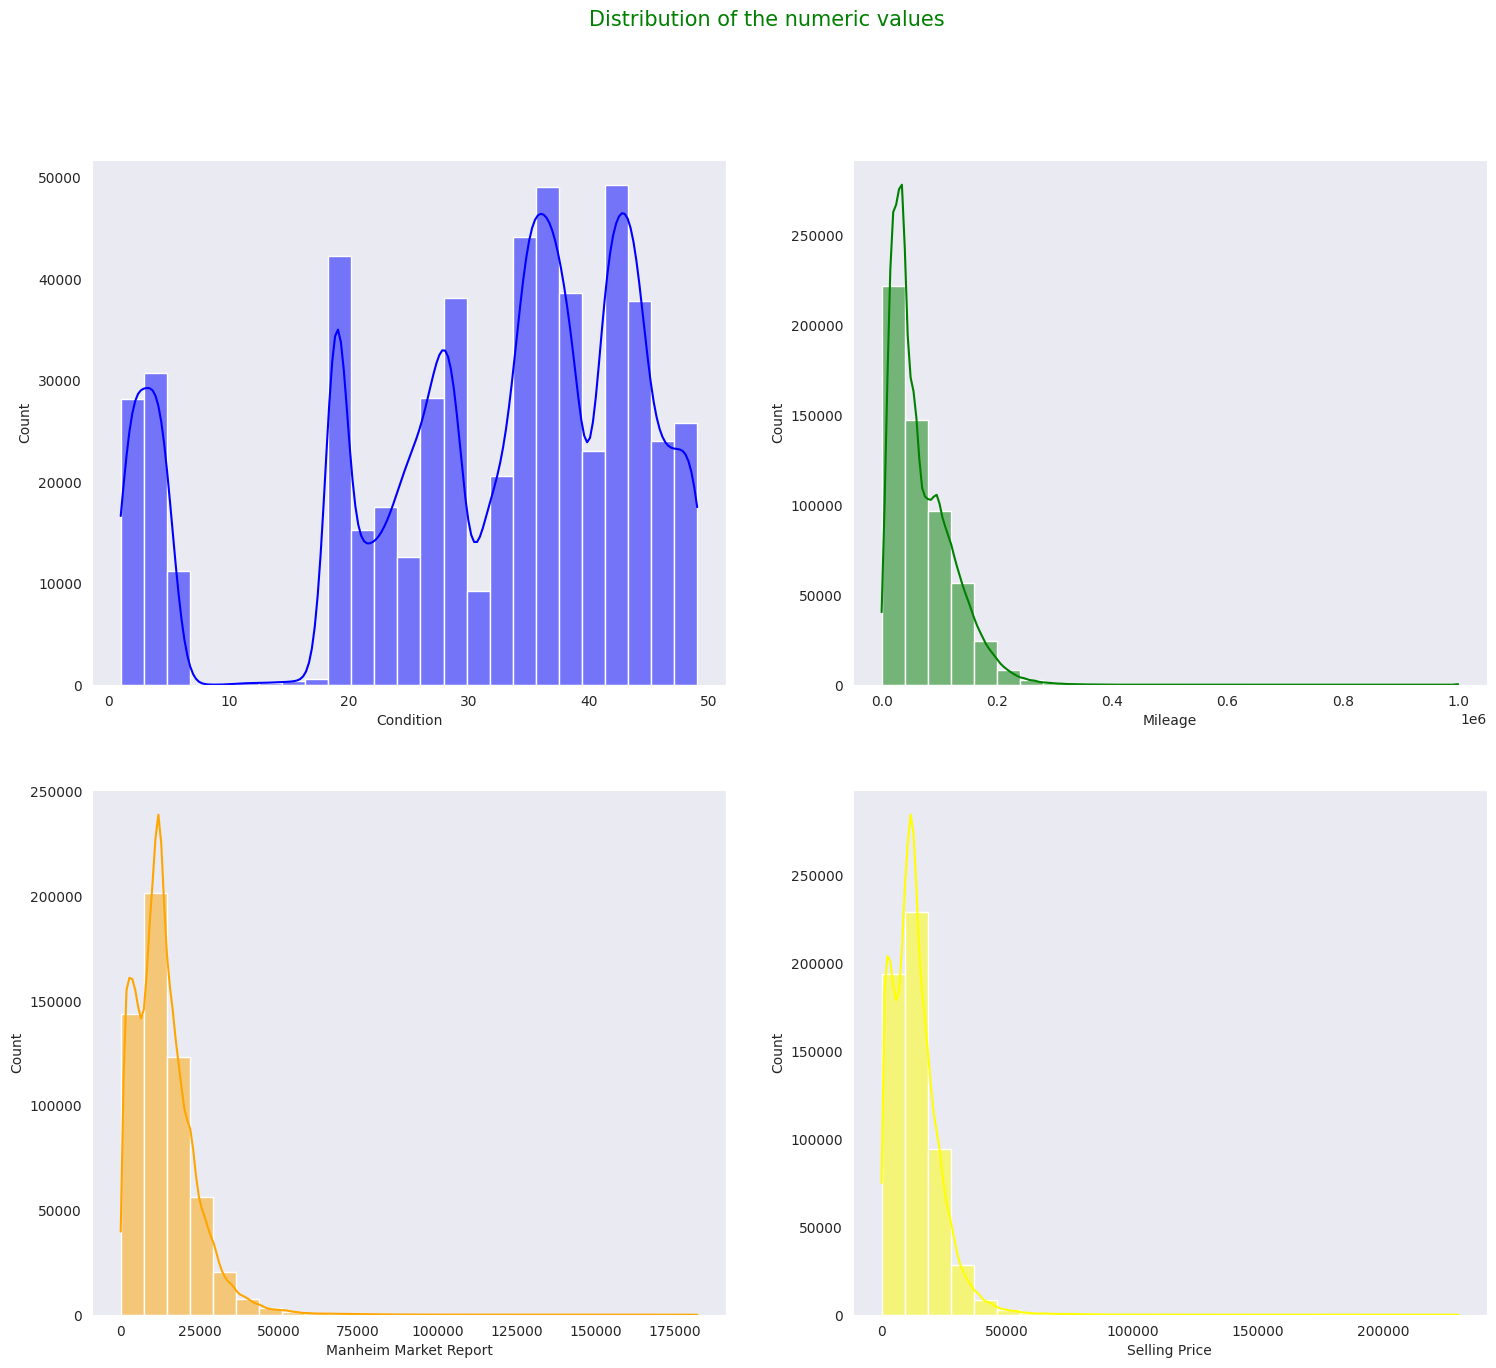

In [49]:
sns.set_style('darkgrid')
plt.figure(figsize=(18,15))
plt.suptitle('Distribution of the numeric values', fontsize = 15, color='green')

colors=['blue','green','orange','yellow']
labels=['Condition','Mileage','Manheim Market Report','Selling Price']
columns = ['condition','odometer','mmr','sellingprice']
for k,i in enumerate(columns):
    plt.subplot(2,2,k+1)
    sns.histplot(df[i], kde=True, color=colors[k], bins=25)
    plt.xlabel(labels[k])
    plt.grid()
plt.show();

In [50]:
print(f"Suspicious absense of the number of the condition indicator on 40: {(df.condition==40).sum()}.  For comparison 39: {(df.condition==39).sum()}, 41: {(df.condition==41).sum()}")

Suspicious absense of the number of the condition indicator on 40: 0.  For comparison 39: 19920, 41: 23073


 - Prices as expected right skewed.
 - Milegae also right skewed.
 - Except suspicious observation on the value 40, condition have peaks around 4, 19, 28 and 42

In [51]:
mask = pd.Series(True, index=df.index)
for col in ['odometer','mmr','sellingprice']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    low = q1 - iqr*1.5
    high =q3 + iqr*1.5
    mask &= (df[col]>=low)&(df[col]<=high)
print(f"\033[34mNumber of outliers from mileage, mmr, price\033[0m: {len(df)-mask.sum()}, {((len(df)-mask.sum())/len(df))*100:.2f}")

Number of outliers from mileage, mmr, price: 28417, 5.09


In [126]:
q1 = df['odometer'].quantile(0.25)
q3 = df['odometer'].quantile(0.75)
iqr = q3-q1
high =q3 + iqr*1.5
(df['odometer'] > high).sum()

10375

In [52]:
df_outless = df_clean[mask].copy()

/tmp/ipykernel_2544/1302520456.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_outless = df_clean[mask].copy()


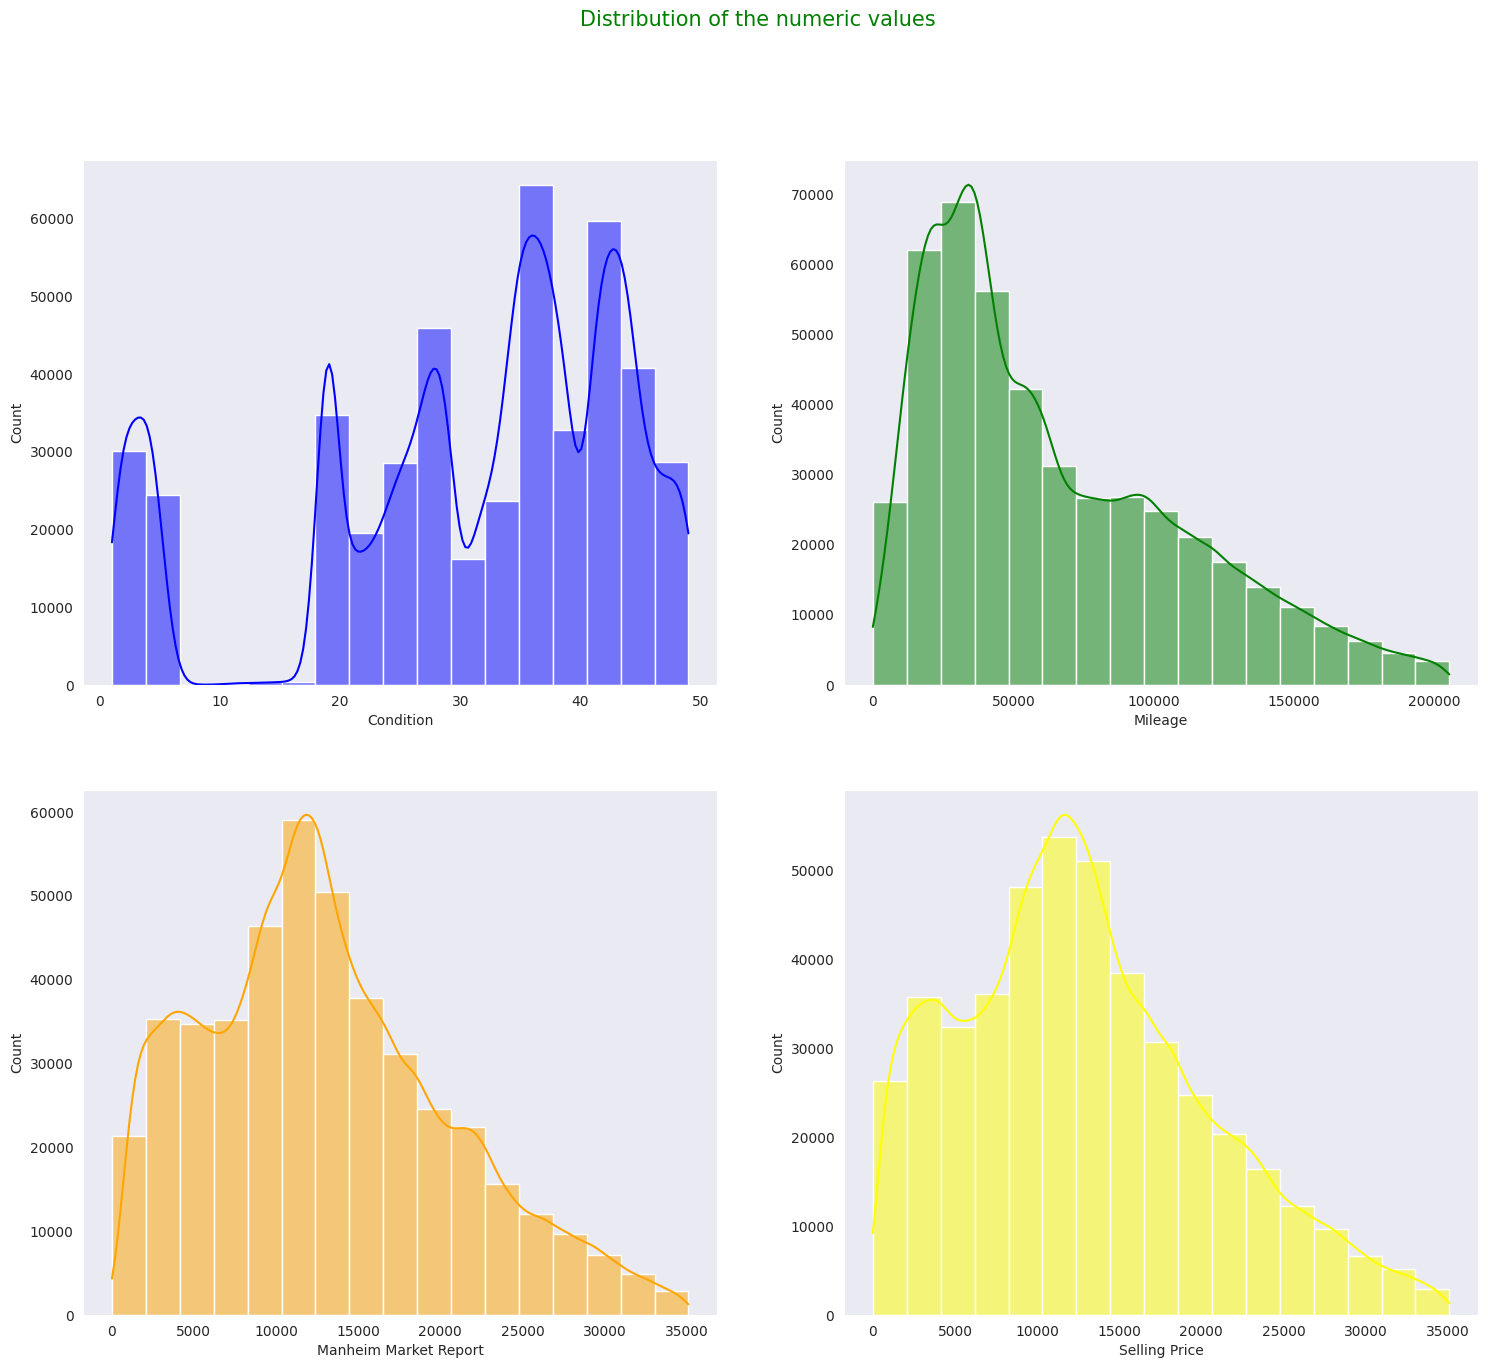

In [53]:
plt.figure(figsize=(18,15))
plt.suptitle('Distribution of the numeric values', fontsize = 15, color='green')

colors=['blue','green','orange','yellow']
labels=['Condition','Mileage','Manheim Market Report','Selling Price']
columns = ['condition','odometer','mmr','sellingprice']
for k,i in enumerate(columns):
    plt.subplot(2,2,k+1)
    sns.histplot(df_outless[i], kde=True, color=colors[k], bins=17)
    plt.xlabel(labels[k])
    plt.grid()
plt.show();

### Correlation between Manheim Market Report and the Selling Price
Basically these two parameters almost symmetric but not exactly equal

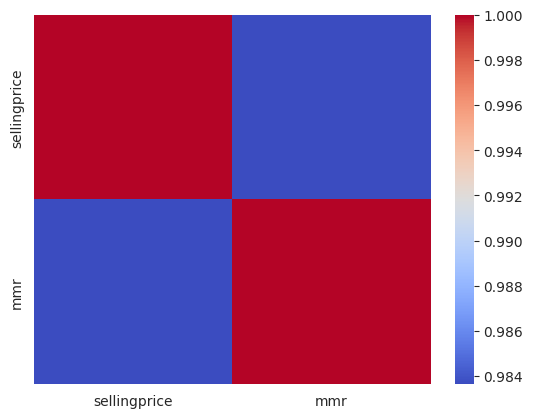

In [54]:
sns.heatmap(df[['sellingprice','mmr']].corr(), cmap='coolwarm');

### Generalizing, transforming, categorizing parameters for EDA

In [55]:
# mozhno bilo bi i bez clean/outless razdelenia
bins_y = [df.year.min(), 1995, 2010, df.year.max()]
labels_y = ['old','used_car','new']
bins_s = [df.sellingprice.min(), 12000, 18000 , 30000, df.sellingprice.max()]
bins_ss = [df.sellingprice.min(), 12000, 18000 , 30000, 50000, df.sellingprice.max()]
labels_s = ['cheap','budget','mid','entry_lux']
labels_ss = ['cheap','budget','mid','entry_lux', 'high-end']

for d in [df_clean, df_outless]:
    d['year_cat'] = pd.cut(d['year'], bins=bins_y, labels=labels_y, include_lowest=True)
    if d is df_clean:
        d['sellingprice_cat'] = pd.cut(d['sellingprice'], bins=bins_ss, labels=labels_ss, include_lowest=True)
    else:
        d['sellingprice_cat'] = pd.cut(d['sellingprice'], bins=bins_s, labels=labels_s, include_lowest=True)

In [56]:
bins_o = [df.odometer.min(), 50000, 100000, df.odometer.max()]
labels_o = ['low','average', 'high']
for d in [df_clean, df_outless]:
    d['odometer_cat']=pd.cut(d.odometer, bins=bins_o, labels=labels_o)

In [63]:
''' kto pridumal peresozdovat novie imena odnogo i togozhe'''

def normalize_body(val):
    if pd.isna(val):
        return np.nan
    v = val.lower()

    if 'cab' in v:
        return 'cab'
    if 'sedan' in v:
        return 'sedan'
    if 'koup' in v or 'coupe' in v:
        return 'coupe'
    if 'hatch' in v:
        return 'hatchback'
    if 'mini' in v:
        return 'minivan'
    if 'convert' in v:
        return 'convertible'
    if 'wagon' in v:
        return 'wagon'
    if 'van' in v:
        return 'van'
    if 'suv' in v:
        return 'suv'

    return 'other'
df_clean['body']=df_clean['body'].apply(normalize_body)

import re

def normalize_make(s: str):
    if pd.isna(s):
        return s
    
    s = s.lower().strip()

    # базовая очистка
    s = re.sub(r'\b(tk|truck)\b', '', s)
    s = re.sub(r'\s+', ' ', s).strip()

    # алиасы брендов
    alias_map = {
        'vw': 'volkswagen',
        'landrover': 'land rover',
        'mercedes': 'mercedes-benz',
        'mercedes-b': 'mercedes-benz',
        'gmc truck': 'gmc',
        'ford tk': 'ford',
        'chev': 'chevrolet'
    }

    return alias_map.get(s, s)
df_clean['make'] = df_clean['make'].apply(normalize_make)

In [64]:
df['make'] = df['make'].apply(normalize_make)

In [65]:
models_mean = df.groupby('model')['sellingprice'].mean()
models_median = df.groupby('model')['sellingprice'].median()
brand_mean = df.groupby('make')['sellingprice'].mean()
brand_median = df.groupby('make')['sellingprice'].median()
transmission_mean = df.groupby('transmission')['sellingprice'].mean()
transmission_median = df.groupby('transmission')['sellingprice'].median()

In [66]:
df_clean['saledate'] = pd.to_datetime(df_clean['saledate'], utc=True).dt.tz_convert(None)
df_clean['sale_year']=df_clean['saledate'].dt.year
df_clean['sale_month']=df_clean['saledate'].dt.month
df_clean['sale_day']=df_clean['saledate'].dt.day
df_clean['sale_weekday']=df_clean['saledate'].dt.weekday

### EDA

In [67]:
df_eda = df_clean[['year','make','transmission','body','state','condition','odometer','color','interior','mmr','sellingprice','year_cat','sellingprice_cat','odometer_cat','sale_month','sale_day','sale_weekday']]

In [68]:
# transmission, brand
dict_vc = {'brand':'make','transmission':'transmission','year':'year_cat','price':'sellingprice_cat','mileage':'odometer_cat'}
dict_value_counts = {}
for k,i in dict_vc.items():
    dict_value_counts[k] = df_eda[i].value_counts()    

In [72]:
transmission_aggr = pd.concat([transmission_mean, transmission_median],axis=1, names=['transmission','avg','median'])
brand_aggr = pd.concat([brand_mean,brand_median],axis=1, names=['brand','avg','median'])

Average and Median of car price by transmission:
               sellingprice  sellingprice
transmission                            
automatic     13540.406866       12100.0
manual        11211.448358        8600.0

Average and Median of car price by brand:
                 sellingprice  sellingprice
make                                      
acura           13983.597705       14800.0
airstream       71000.000000       71000.0
aston martin    54812.000000       51000.0
audi            19910.834609       18500.0
bentley         74367.672414       62250.0
bmw             21474.030347       20100.0
buick           10709.563562       10600.0
cadillac        15072.469655       14000.0
chevrolet       11939.195039       10500.0
chrysler        11068.147114       10200.0
daewoo            400.000000         300.0
dodge           11163.730665       10500.0
dot               500.000000         500.0
ferrari        127210.526316      124000.0
fiat            10367.487861       10100.0
fisker     

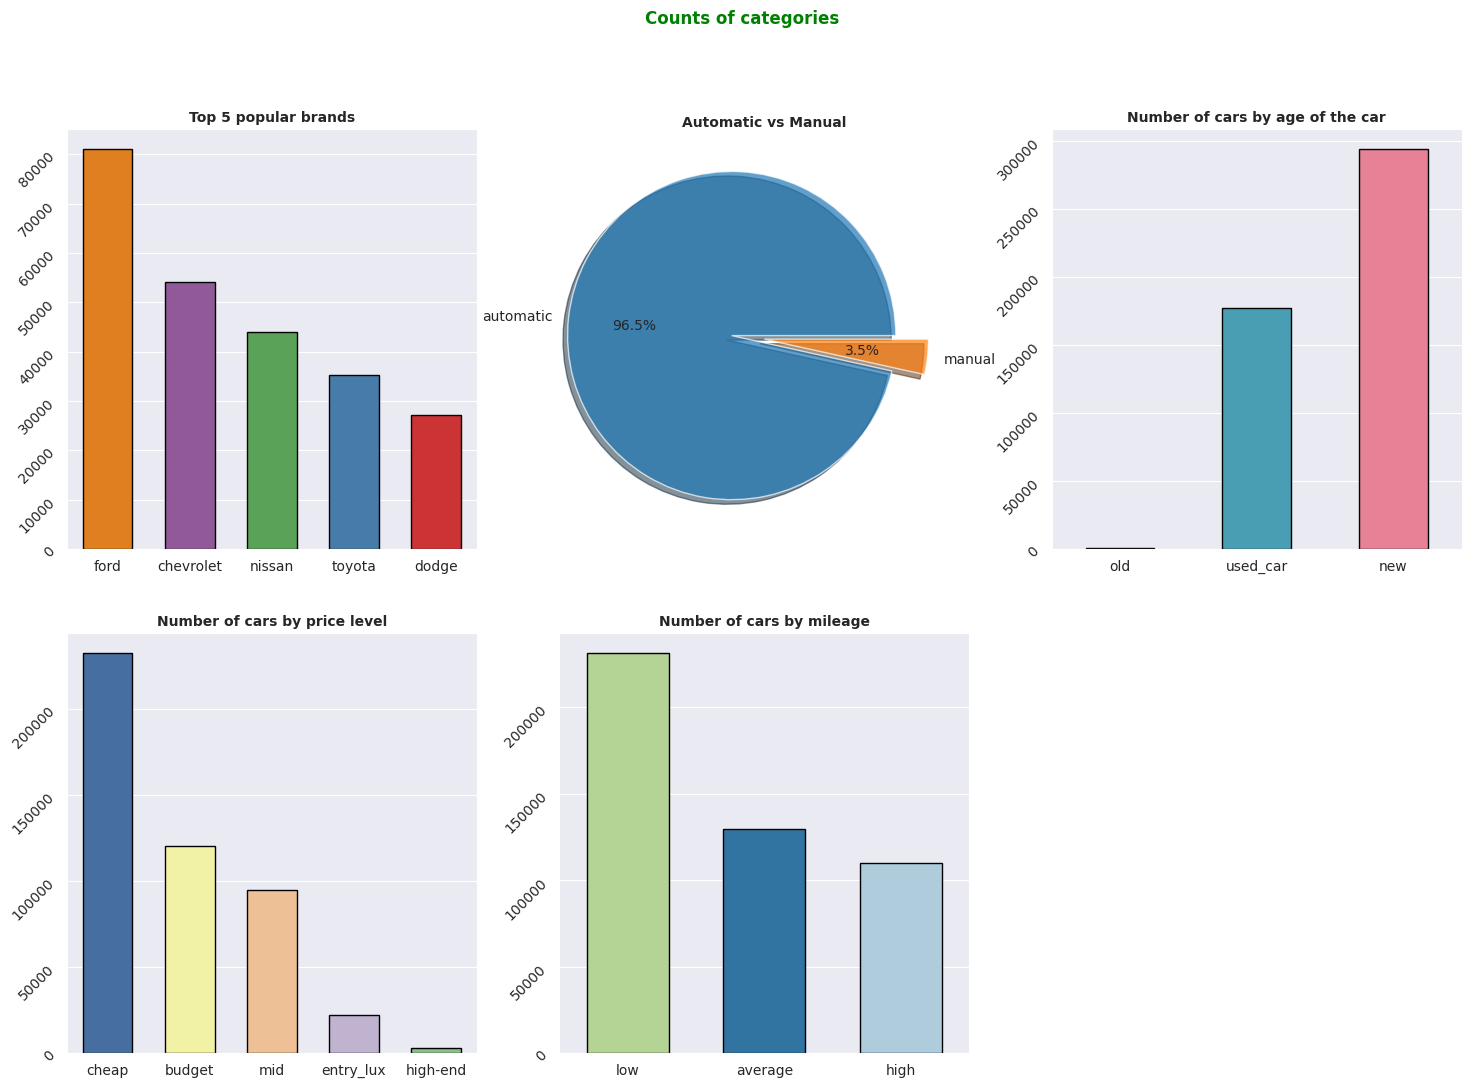

In [83]:
print('\033[34mAverage and Median of car price by transmission:\033[0m\n',transmission_aggr)
print('\n\033[34mAverage and Median of car price by brand:\033[0m\n',brand_aggr)

plt.figure(figsize=(18,12))
plt.suptitle('Counts of categories', fontweight='bold', color='green')

plt.subplot(2,3,1)
sns.barplot(x=dict_value_counts['brand'][:5].index, y=dict_value_counts['brand'][:5], palette='Set1', hue=dict_value_counts['brand'][:5], legend=False, width=0.6, edgecolor='black')
plt.title('Top 5 popular brands', fontweight='bold', fontsize=10)
plt.yticks(rotation=45)
plt.xlabel('')
plt.ylabel('')

exp = [0.2,0]
plt.subplot(2,3,2)
plt.pie(dict_value_counts['transmission'].values, labels=dict_value_counts['transmission'].index, autopct='%1.1f%%', explode=exp, shadow=True, wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'alpha': 0.7})
plt.title('Automatic vs Manual', fontweight='bold', fontsize=10)
plt.xlabel('')
plt.ylabel('')

plt.subplot(2,3,3)
sns.barplot(x=dict_value_counts['year'].index, y=dict_value_counts['year'], palette='husl', hue=dict_value_counts['year'], legend=False, width=0.5, edgecolor='black')
plt.title('Number of cars by age of the car', fontweight='bold', fontsize=10)
plt.yticks(rotation=45)
plt.xlabel('')
plt.ylabel('')

plt.subplot(2,3,4)
sns.barplot(x=dict_value_counts['price'].index, y=dict_value_counts['price'], palette='Accent', hue=dict_value_counts['price'], legend=False, width=0.6, edgecolor='black')
plt.title('Number of cars by price level', fontweight='bold', fontsize=10)
plt.yticks(rotation=45)
plt.xlabel('')
plt.ylabel('')

plt.subplot(2,3,5)
sns.barplot(x=dict_value_counts['mileage'].index, y=dict_value_counts['mileage'], palette='Paired', hue=dict_value_counts['mileage'], legend=False, width=0.6, edgecolor='black')
plt.title('Number of cars by mileage', fontweight='bold', fontsize=10)
plt.yticks(rotation=45)
plt.xlabel('')
plt.ylabel('')

plt.show();


In [84]:
pd.reset_option('display.max_rows')

In [86]:
# transmission, brand
# year_cat, odometer_cat, sale_month, sale_day
aggr_avg = {}
for i in ['year_cat', 'odometer_cat', 'sale_month', 'sale_weekday']:
    aggr_avg[i] = df_eda.groupby(i, observed=False)['sellingprice'].mean()

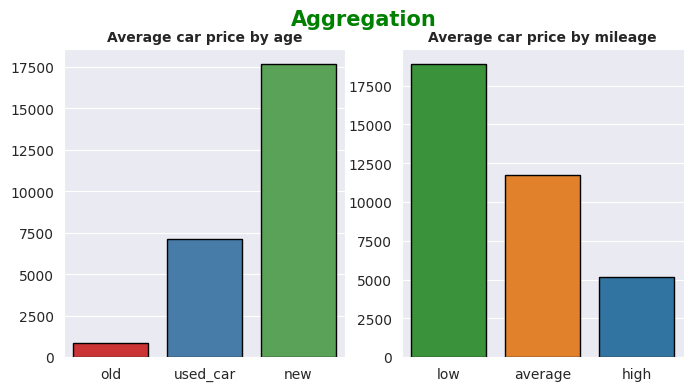

In [87]:
plt.figure(figsize=(8,4))
plt.suptitle('Aggregation', fontsize=15, color='green', fontweight='bold')

plt.subplot(1,2,1)
sns.barplot(x=aggr_avg['year_cat'].keys(), y=aggr_avg['year_cat'], palette='Set1', hue=aggr_avg['year_cat'], legend=False, edgecolor='black')
plt.title('Average car price by age', fontweight='bold', fontsize=10)
plt.xlabel('')
plt.ylabel('')

plt.subplot(1,2,2)
sns.barplot(x=aggr_avg['odometer_cat'].keys(), y=aggr_avg['odometer_cat'], palette='tab10', hue=aggr_avg['odometer_cat'], legend=False, edgecolor='black')
plt.title('Average car price by mileage', fontweight='bold', fontsize=10)
plt.xlabel('')
plt.ylabel('')

plt.show();

In [152]:
daily_sales = df_clean.groupby(['saledate', 'sale_weekday']).size().reset_index(name='num_cars')
avgnum_weekday = daily_sales.groupby('sale_weekday')['num_cars'].mean().reset_index(name='avg_cars_sold')
avgnum_weekday

,sale_weekday,avg_cars_sold
0,0,191.303279
1,1,151.792015
2,2,120.400186
3,3,75.616883
4,4,58.288889
5,6,76.640288


- There is no saturday in selling date

In [154]:
set(range(7)) - set(df_clean['sale_weekday'].unique())

{5}

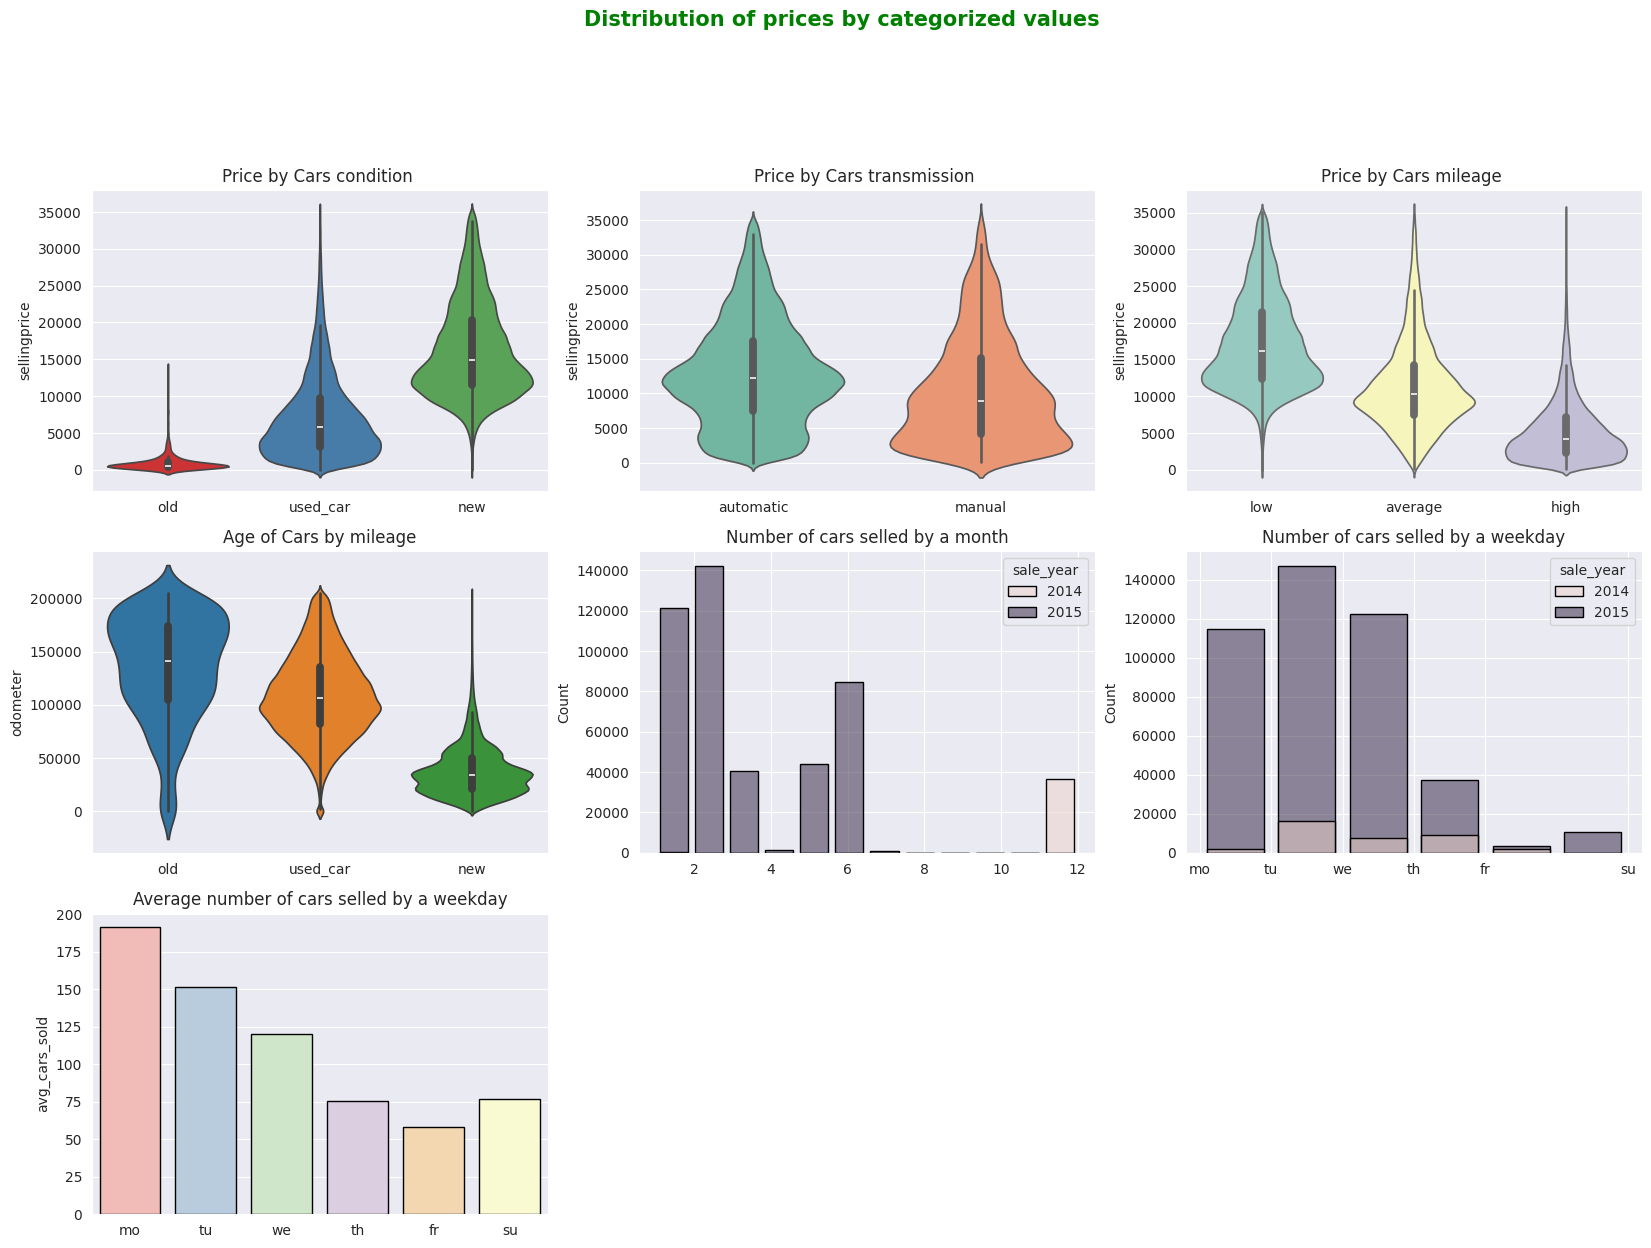

In [161]:
plt.figure(figsize=(20,18))
plt.suptitle('Distribution of prices by categorized values', fontsize=15, color='green', fontweight='bold')

plt.subplot(4,3,1)
sns.violinplot(data=df_outless, x='year_cat', y='sellingprice', palette='Set1', hue='year_cat', legend=False)
plt.title('Price by Cars condition ')
plt.xlabel('')

plt.subplot(4,3,2)
sns.violinplot(data=df_outless, x='transmission', y='sellingprice', palette='Set2', hue='transmission', legend=False)
plt.title('Price by Cars transmission ')
plt.xlabel('')

plt.subplot(4,3,3)
sns.violinplot(data=df_outless, x='odometer_cat', y='sellingprice', palette='Set3', hue='odometer_cat', legend=False)
plt.title('Price by Cars mileage ')
plt.xlabel('')

plt.subplot(4,3,4)
sns.violinplot(data=df_outless, x='year_cat', y='odometer', palette='tab10', hue='year_cat', legend=False)
plt.title('Age of Cars by mileage')
plt.xlabel('')

plt.subplot(4,3,5)
sns.histplot(data =df_clean, x='sale_month', bins=12, shrink=0.8, edgecolor='black', hue='sale_year')
plt.title('Number of cars selled by a month')
plt.xlabel('')

plt.subplot(4,3,6)
sns.histplot(data =df_clean, x='sale_weekday', bins=6, shrink=0.8, edgecolor='black', hue='sale_year')
plt.title('Number of cars selled by a weekday')
plt.xticks(ticks=[0,1,2,3,4,6],labels=['mo','tu','we','th','fr','su'])
plt.xlabel('')

plt.subplot(4,3,7)
sns.barplot(data =avgnum_weekday, x='sale_weekday', y='avg_cars_sold' , width=0.8, edgecolor='black', palette='Pastel1', hue='sale_weekday', legend=False)
plt.title('Average number of cars selled by a weekday')
plt.xticks(ticks=[0,1,2,3,4,5],labels=['mo','tu','we','th','fr','su'])
plt.xlabel('')

plt.show();

In [95]:
price_year = df_clean.groupby('year')['sellingprice'].aggregate(['mean','median'])
price_saledate = df_clean.groupby

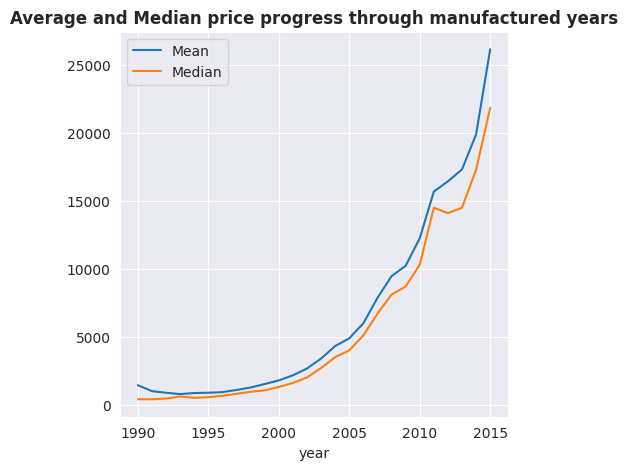

In [124]:
sns.set_style('darkgrid')
plt.figure(figsize=(5,5))
sns.lineplot(x=price_year['mean'].index, y = price_year['mean'].values, label='Mean')
sns.lineplot(x=price_year['median'].index, y = price_year['median'].values, label='Median')
df_clean_five=df_clean.sample(frac=0.05, random_state=42)
plt.title('Average and Median price progress through manufactured years', fontweight='bold')
plt.show()